Beta regression on World Bank Gini index (WDI)

The base model is a **beta regression** to an inequality outcome (**Gini index**) fitted by **maximum likelihood**, with a **logit link for the mean** and **constant precision** (i.e., the “scale/precision” submodel has only an intercept).

We use the attached, already-prepared dataset `reg_df.csv` (exported from R/WDI).


In [1]:
# Core numerics + optimization
import numpy as np
import pandas as pd

from scipy.optimize import minimize
from scipy.special import expit, gammaln

# Display helpers
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


The file `reg_df.csv` is a **country–year panel** assembled from the World Bank's World Development Indicators (WDI), using R's `WDI` package, then cleaned for beta regression.

Each row is one `(country, year)` observation.


- `y_adj` (**response**, used in modeling):  
  The **Gini index** (originally on 0–100 scale in WDI) converted to a proportion in (0, 1), then “squeezed” into the open interval (0, 1) using the Smithson–Verkuilen adjustment  
  \[
  y_{adj} = \frac{y(n-1) + 0.5}{n}, \quad y \in (0,1)
  \]
  where `n` is the number of rows in the regression dataset.

- `year`: calendar year.

- `iso3c`: ISO-3 country code.

- `country`: country name.

- `region`: World Bank region label (categorical).

- `income`: World Bank income group label (categorical).

- `log_gdppc`: log of GDP per capita (constant USD), i.e. `log(NY.GDP.PCAP.KD)`.

- `urban`: urban population (% of total), `SP.URB.TOTL.IN.ZS`.

- `unemp`: unemployment rate (% of total labor force), `SL.UEM.TOTL.ZS`.

- `trade`: trade openness (% of GDP), `NE.TRD.GNFS.ZS`.

- `Unnamed: 0`: an index column carried over from CSV export (not meaningful; we drop it).

In [2]:
# Load the prepared dataset
csv_path = r"reg_df.csv"
df = pd.read_csv(csv_path)

# Drop the leftover index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


,y_adj,year,iso3c,country,region,income,log_gdppc,urban,unemp,trade
0,0.270104,1996,ALB,Albania,Europe & Central Asia,Upper middle income,7.428790,38.899604,13.928,44.411782
1,0.306088,2005,ALB,Albania,Europe & Central Asia,Upper middle income,7.905762,45.993767,15.966,69.116293
2,0.290095,2012,ALB,Albania,Europe & Central Asia,Upper middle income,8.235320,53.863755,13.376,76.968358
3,0.294093,2020,ALB,Albania,Europe & Central Asia,Upper middle income,8.513309,57.140859,11.690,59.520699
4,0.301090,2019,ALB,Albania,Europe & Central Asia,Upper middle income,8.531577,56.763907,11.466,75.382129


The preprocessing was performed in R (using WDI + dplyr) and resulted in this CSV. The key steps were:

1. **Remove aggregates**: keep only actual countries (`region != "Aggregates"`).
2. **Keep the study window**: start around 1990+.
3. **Construct Gini proportion**: `y = gini / 100`.
4. **Ensure open-interval support**: keep `0 < y < 1`.
5. **(Optional but safe) Smithson–Verkuilen adjustment** to keep values strictly inside (0,1):  
   \[
   y_{adj} = \frac{y(n-1) + 0.5}{n}
   \]
6. **Create covariates** like `log_gdppc = log(gdp_pc)`.
7. **Drop rows missing any predictors used in the regression**.


Note: In the modeling that follows, we use only **numerical covariates** — `log_gdppc`, `urban`, `unemp`, `trade`, and `year`.

In [3]:
# Basic shape and missingness
print("Rows, columns:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum())

# Response sanity: must be strictly in (0,1)
y = df["y_adj"].to_numpy()
print("\nResponse y_adj summary:")
display(df["y_adj"].describe())
print("All y_adj in (0,1):", bool(np.all((y > 0) & (y < 1))))

# Quick summaries of predictors
display(df[["log_gdppc", "urban", "unemp", "trade", "year"]].describe())


Rows, columns: (2093, 10)

Missing values per column:


y_adj        0
year         0
iso3c        0
country      0
region       0
income       0
log_gdppc    0
urban        0
unemp        0
trade        0
dtype: int64


Response y_adj summary:


count    2093.000000
mean        0.372702
std         0.086239
min         0.202135
25%         0.308087
50%         0.352067
75%         0.424034
max         0.710905
Name: y_adj, dtype: float64

All y_adj in (0,1): True


,log_gdppc,urban,unemp,trade,year
count,2093.000000,2093.000000,2093.000000,2093.000000,2093.000000
mean,9.023439,64.636338,7.969599,85.885467,2009.182035
std,1.327749,18.481512,5.268500,49.086626,8.588301
min,5.425824,10.215852,0.140000,13.753054,1991.000000
25%,8.111073,54.382847,4.415000,52.693370,2003.000000
50%,9.012798,67.353879,6.700000,74.590296,2010.000000
75%,10.199848,78.478536,10.212000,107.619709,2016.000000
max,11.629978,99.031013,37.320000,412.177170,2024.000000


A beta regression is fitted:

- **Mean submodel**: logit link  
  $
  \text{logit}(\mu_i) = x_i^\top \beta
  $
- **Precision** (a.k.a. “scale”) **constant** across observations  
  $
  \log(\phi) = \alpha_0
  $
- **Likelihood**  
  $
  y_i \sim \text{Beta}(a_i, b_i), \quad a_i = \mu_i\phi,\; b_i=(1-\mu_i)\phi
  $


In [4]:
# Build the design matrix for the mean model:
#   Intercept + continuous covariates + year (continuous-only)
#
# Constant precision: only one parameter log_phi.

cont_cols = ["log_gdppc", "urban", "unemp", "trade", "year"]

X_cont = df[cont_cols].copy()

# Continuous-only design; no categorical dummies
X = X_cont.copy()
X.insert(0, "Intercept", 1.0)

y = df["y_adj"].to_numpy(dtype=float)
X_mat = X.to_numpy(dtype=float)

print("Design matrix shape:", X_mat.shape)
print("Number of parameters in mean model (beta):", X_mat.shape[1])

# 90/10 train-test split (deterministic)
n = X_mat.shape[0]
rng = np.random.default_rng(123)
perm = rng.permutation(n)
n_train = int(0.9 * n)
train_idx = perm[:n_train]
test_idx = perm[n_train:]

X_mat_train = X_mat[train_idx]
X_mat_test = X_mat[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)
X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)

print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")


Design matrix shape: (2093, 6)
Number of parameters in mean model (beta): 6
Train size: 1883, Test size: 210


Maximum-likelihood fitting (manual beta regression)


For observation \(i\):

- \(\mu_i = \text{logit}^{-1}(x_i^\top\beta)\)
- \(\phi = \exp(\text{log\_phi})\) (constant)

Then:

\[
\ell_i(\beta,\phi) =
\log \Gamma(\phi) - \log \Gamma(\mu_i\phi) - \log \Gamma((1-\mu_i)\phi)
+ (\mu_i\phi - 1)\log y_i + ((1-\mu_i)\phi - 1)\log(1-y_i)
\]



In [5]:
def neg_loglik(params, y, X):
    """Negative log-likelihood for beta regression with logit mean and constant precision.

    params = [beta_0, ..., beta_{p-1}, log_phi]
    """
    beta = params[:-1]
    log_phi = params[-1]
    phi = np.exp(log_phi)

    eta = X @ beta
    mu = expit(eta)

    # beta distribution parameters
    a = mu * phi
    b = (1 - mu) * phi

    # log-likelihood (vectorized)
    ll = (
        gammaln(phi) - gammaln(a) - gammaln(b)
        + (a - 1) * np.log(y)
        + (b - 1) * np.log(1 - y)
    )

    return -np.sum(ll)


# Initial parameters
p = X_mat_train.shape[1]
init = np.zeros(p + 1)   # betas + log_phi
init[-1] = 0.0           # log_phi -> phi=1 start

res = minimize(
    neg_loglik,
    init,
    args=(y_train, X_mat_train),
    method="BFGS",
    options={"disp": True, "maxiter": 500}
 )

print("\nConverged:", res.success)
print("Message:", res.message)
print("Final negative log-likelihood (train):", res.fun)

         Current function value: -2253.730053
         Iterations: 19
         Function evaluations: 566
         Gradient evaluations: 68

Converged: False
Message: Desired error not necessarily achieved due to precision loss.
Final negative log-likelihood (train): -2253.7300527914567


/Users/zichuanchen/miniconda3/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/Users/zichuanchen/miniconda3/lib/python3.13/site-packages/scipy/optimize/_minimize.py:780: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


Report coefficients (mean model) and constant precision


In [6]:
beta_hat = res.x[:-1]
log_phi_hat = res.x[-1]
phi_hat = float(np.exp(log_phi_hat))

# Approximate covariance from inverse Hessian
# (BFGS returns an approximation to the inverse Hessian)
Hinv = np.asarray(res.hess_inv)
se = np.sqrt(np.diag(Hinv))

param_names = list(X.columns) + ["log_phi"]
est = np.r_[beta_hat, log_phi_hat]

out = pd.DataFrame({
    "param": param_names,
    "estimate": est,
    "std_err": se,
    "z": est / se
})

# Convert log_phi -> phi for readability
phi_row = pd.DataFrame({
    "param": ["phi (precision)"],
    "estimate": [phi_hat],
    "std_err": [np.nan],
    "z": [np.nan]
})

display(out.head(15))
display(phi_row)


,param,estimate,std_err,z
0,Intercept,11.917745,1.767378,6.743177
1,log_gdppc,-0.149342,0.009666,-15.450671
2,urban,0.006662,0.000649,10.270690
3,unemp,-0.002502,0.001467,-1.705310
4,trade,-0.001296,0.000168,-7.727630
5,year,-0.005670,0.000882,-6.424763
6,log_phi,3.741608,0.033106,113.019800


,param,estimate,std_err,z
0,phi (precision),42.165718,NaN,NaN


Fitted means and a quick calibration check

In [7]:
# Fitted means on train and test, plus quick calibration on TEST
mu_hat_train = expit(X_mat_train @ beta_hat)
mu_hat_test = expit(X_mat_test @ beta_hat)

df_train = df_train.copy()
df_test = df_test.copy()
df_train["mu_hat"] = mu_hat_train
df_test["mu_hat"] = mu_hat_test

# Quick summaries on test set
display(df_test[["y_adj", "mu_hat"]].describe())

# Simple predictive error summaries on TEST
err = df_test["y_adj"] - df_test["mu_hat"]
print("TEST MAE:", float(np.mean(np.abs(err))))
print("TEST RMSE:", float(np.sqrt(np.mean(err**2))))

# Show a few test rows
display(df_test[["country", "iso3c", "year", "y_adj", "mu_hat", "region", "income"]].head(10))

,y_adj,mu_hat
count,210.000000,210.000000
mean,0.372082,0.373940
std,0.087536,0.037205
min,0.240117,0.239373
25%,0.308587,0.346490
50%,0.351067,0.378539
75%,0.422535,0.402039
max,0.647933,0.444669


TEST MAE: 0.06216809598876995
TEST RMSE: 0.07774836047123175


,country,iso3c,year,y_adj,mu_hat,region,income
0,Kazakhstan,KAZ,2002,0.348069,0.380337,Europe & Central Asia,Upper middle income
1,Costa Rica,CRI,1993,0.459019,0.385294,Latin America & Caribbean,Upper middle income
2,"Congo, Rep.",COG,2005,0.473012,0.403429,Sub-Saharan Africa,Lower middle income
3,Latvia,LVA,1996,0.316083,0.406473,Europe & Central Asia,High income
4,Bulgaria,BGR,2018,0.413039,0.363663,Europe & Central Asia,High income
5,Ecuador,ECU,2019,0.457019,0.382369,Latin America & Caribbean,Upper middle income
6,Eswatini,SWZ,2016,0.545979,0.321491,Sub-Saharan Africa,Lower middle income
7,Uruguay,URY,2006,0.459019,0.414785,Latin America & Caribbean,High income
8,Mexico,MEX,2012,0.496002,0.390163,Latin America & Caribbean,Upper middle income
9,Dominican Republic,DOM,2013,0.477010,0.402787,Latin America & Caribbean,Upper middle income


Visualizing Predictions

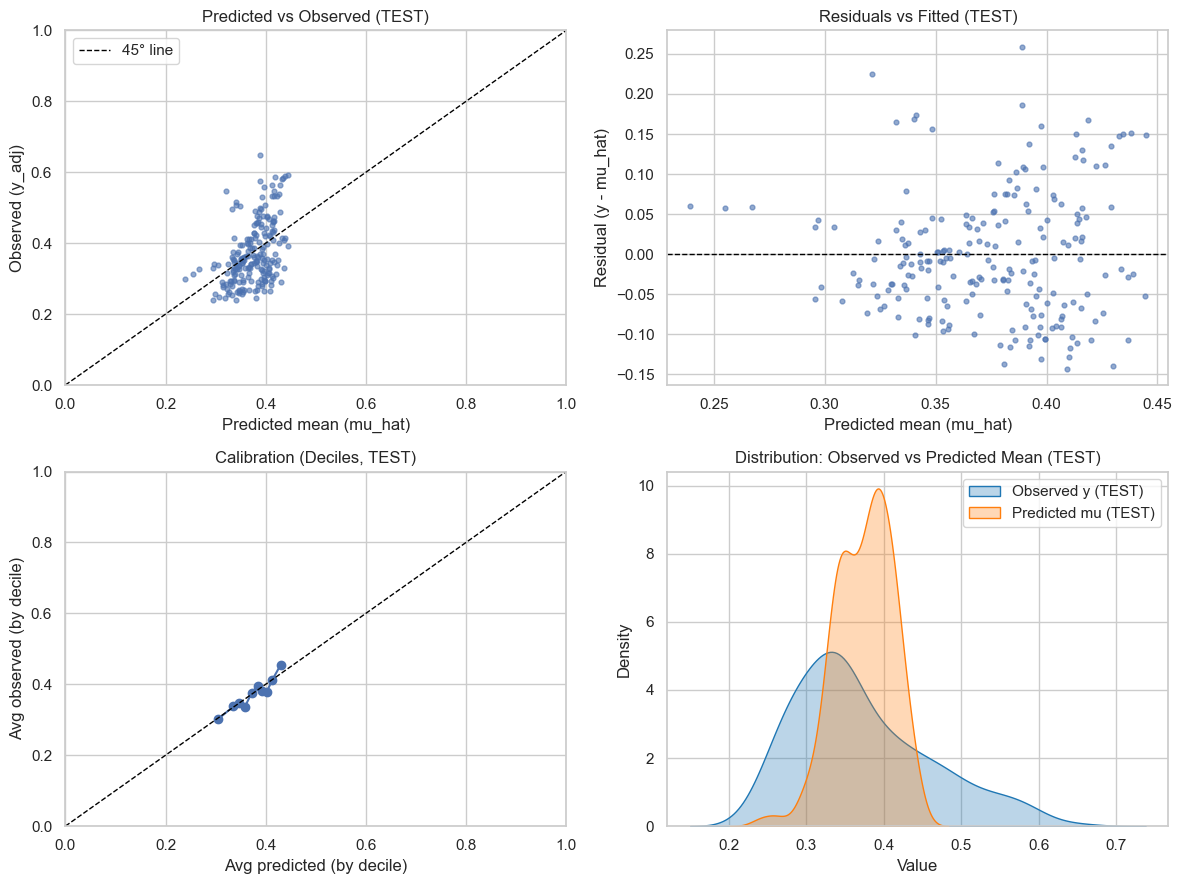

In [8]:
# Visualization of prediction results (TEST set only)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

assert "mu_hat" in df_test.columns and "y_adj" in df_test.columns, "Expected columns missing in df_test"

y_obs = df_test["y_adj"].to_numpy()
y_hat = df_test["mu_hat"].to_numpy()
resid = y_obs - y_hat

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1) Predicted vs Observed (TEST)
ax = axes[0, 0]
ax.scatter(y_hat, y_obs, s=12, alpha=0.6)
ax.plot([0, 1], [0, 1], color="black", lw=1, linestyle="--", label="45° line")
ax.set_xlabel("Predicted mean (mu_hat)")
ax.set_ylabel("Observed (y_adj)")
ax.set_title("Predicted vs Observed (TEST)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

# 2) Residuals vs Fitted (TEST)
ax = axes[0, 1]
ax.scatter(y_hat, resid, s=12, alpha=0.6)
ax.axhline(0.0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Predicted mean (mu_hat)")
ax.set_ylabel("Residual (y - mu_hat)")
ax.set_title("Residuals vs Fitted (TEST)")

# 3) Calibration by deciles (TEST)
ax = axes[1, 0]
bins = pd.qcut(y_hat, q=10, duplicates="drop")
calib = (df_test.assign(bin=bins)
         .groupby("bin", observed=True)
         .agg(mean_pred=("mu_hat", "mean"), mean_obs=("y_adj", "mean"))
         .reset_index(drop=True))
ax.plot(calib["mean_pred"], calib["mean_obs"], marker="o")
ax.plot([0, 1], [0, 1], color="black", lw=1, linestyle="--")
ax.set_xlabel("Avg predicted (by decile)")
ax.set_ylabel("Avg observed (by decile)")
ax.set_title("Calibration (Deciles, TEST)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 4) Distribution overlay (TEST)
ax = axes[1, 1]
sns.kdeplot(y_obs, ax=ax, label="Observed y (TEST)", fill=True, alpha=0.3, color="#1f77b4", clip=(0,1))
sns.kdeplot(y_hat, ax=ax, label="Predicted mu (TEST)", fill=True, alpha=0.3, color="#ff7f0e", clip=(0,1))
ax.set_xlabel("Value")
ax.set_title("Distribution: Observed vs Predicted Mean (TEST)")
ax.legend()

plt.tight_layout()
plt.show()

Updated Model for GP Density Correction (Hyvärinen + Variational ELBO)

In [9]:
# Setup: PyTorch + helpers (updated model)
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from dataclasses import dataclass

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)
np.random.seed(0)

# Use only continuous predictors for the GP inputs (keeps ARD size reasonable)
gp_cols = ["log_gdppc", "urban", "unemp", "trade", "year"]
X_gp_train = df_train[gp_cols].copy()
X_gp_test = df_test[gp_cols].copy()
X_gp_all = df[gp_cols].copy()

# Min-max scale to [0,1] per-dimension using FULL data (train + test)
x_min = X_gp_all.min(axis=0)
x_max = X_gp_all.max(axis=0)
X_gp_scaled = (X_gp_train - x_min) / (x_max - x_min + 1e-12)
X_gp_scaled = X_gp_scaled.to_numpy(dtype=float)

# Base Beta parameters for each TRAIN row from the fitted model
mu_base_train = mu_hat_train   # from earlier cell
phi_base_original = phi_hat    # constant precision (original scale for visualization)

# Scale up precision for training (larger scale)
PHI_SCALE_FACTOR = 2  # Adjust this to control how much to scale up
phi_base = phi_base_original * PHI_SCALE_FACTOR

print(f"Original precision phi: {phi_base_original:.4f}")
print(f"Training precision phi (scaled by {PHI_SCALE_FACTOR}): {phi_base:.4f}")

a_base = mu_base_train * phi_base
b_base = (1.0 - mu_base_train) * phi_base

# Clamp y to open interval (TRAIN)
eps = 1e-6
y_np = np.clip(df_train["y_adj"].to_numpy(dtype=float), eps, 1.0 - eps)

# Torch tensors (TRAIN)
x_t = torch.from_numpy(X_gp_scaled)             # (n_train, d)
y_t = torch.from_numpy(y_np)                    # (n_train,)
a_t = torch.from_numpy(a_base)                  # (n_train,)
b_t = torch.from_numpy(b_base)                  # (n_train,)

def beta_pdf_torch(y, a, b):
    # y in (0,1). log pdf then exp for stability
    logB = torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b)
    logp = (a - 1.0) * torch.log(y) + (b - 1.0) * torch.log1p(-y) - logB
    return torch.exp(logp)

def beta_cdf_torch(y, a, b):
    # Torch lacks betainc; fallback to SciPy and convert back
    from scipy.special import betainc
    y_np = y.detach().cpu().numpy()
    a_np = a.detach().cpu().numpy()
    b_np = b.detach().cpu().numpy()
    cdf_np = betainc(a_np, b_np, y_np)
    return torch.from_numpy(cdf_np).to(y.dtype).to(y.device)

def beta_derivatives(y, a, b):
    # Closed-form derivatives wrt y:
    # d/dy log g = (a-1)/y - (b-1)/(1-y)
    # d2/dy2 log g = -(a-1)/y^2 - (b-1)/(1-y)^2
    g = beta_pdf_torch(y, a, b)
    dlog = (a - 1.0) / y - (b - 1.0) / (1.0 - y)
    d2log = -(a - 1.0) / (y**2) - (b - 1.0) / ((1.0 - y) ** 2)
    gy = g * dlog
    gyy = g * (dlog**2 + d2log)
    return g, gy, gyy

# Compute base terms and the z-transform (TRAIN)
with torch.no_grad():
    g_t, gy_t, gyy_t = beta_derivatives(y_t, a_t, b_t)
    z_t = torch.clamp(beta_cdf_torch(y_t, a_t, b_t), 1e-6, 1-1e-6)  # (n_train,)

# Build training inputs V = concat(x, z)
V_t = torch.cat([x_t, z_t.reshape(-1,1)], dim=1)  # (n_train, d+1)
n, d = x_t.shape
print(f"GP TRAIN inputs shape V: {V_t.shape}  (n_train={n}, d_x={d})")


Original precision phi: 42.1657
Training precision phi (scaled by 2): 84.3314
GP TRAIN inputs shape V: torch.Size([1883, 6])  (n_train=1883, d_x=5)


In [ ]:
# Kernel with ARD (x) and separate z lengthscale; derivative blocks wrt z
@dataclass
class KernelParams:
    log_sigma2: float = math.log(0.9168**2) 
    # ARD for x dims; initialize to moderate lengthscales
    log_lx2: torch.Tensor = None  # to be set after data dims known
    log_lz2: float = math.log(0.7829**2) 

    def finalize(self, d_x):
        if self.log_lx2 is None:
            self.log_lx2 = torch.log(torch.full((d_x,), 0.2117**2, dtype=torch.get_default_dtype())) 
        return self

    @property
    def sigma2(self): return math.exp(self.log_sigma2)
    @property
    def lx2(self):    return torch.exp(self.log_lx2)
    @property
    def lz2(self):    return math.exp(self.log_lz2)

class RBF_SE_ARD(nn.Module):
    def __init__(self, kp: KernelParams, d_x: int):
        super().__init__()
        kp = kp.finalize(d_x)
        self.register_buffer("lx2", kp.lx2.detach().clone())  # (d_x,)
        self.register_buffer("lz2", torch.tensor(kp.lz2))     # scalar
        self.register_buffer("sigma2", torch.tensor(kp.sigma2))

    def dx2(self, X1, X2):
        # X1: (n, d_x), X2: (m, d_x)
        # returns pairwise scaled squared distance along x dims
        x1 = X1[:, None, :]
        x2 = X2[None, :, :]
        dist2 = (x1 - x2) ** 2 / self.lx2
        return dist2.sum(-1)  # (n, m)

    def dz(self, z1, z2):
        return z1[:, None] - z2[None, :]  # (n, m)

    def K_base(self, X1, z1, X2, z2):
        dx2 = self.dx2(X1, X2)
        dz = self.dz(z1, z2)
        dz2 = (dz**2) / self.lz2
        return self.sigma2 * torch.exp(-(dx2 + dz2))  # (n,m)

    # Cov(f, f'_z') = ∂/∂z' k
    def delta_01(self, V, U):
        X1, z1 = V[:, :-1], V[:, -1]
        X2, z2 = U[:, :-1], U[:, -1]
        K = self.K_base(X1, z1, X2, z2)
        dz = self.dz(z1, z2)
        return K * (2.0 * dz / self.lz2)

    # Cov(f'_z, f'_z') = ∂^2/(∂z ∂z') k
    def delta_11(self, V, U):
        X1, z1 = V[:, :-1], V[:, -1]
        X2, z2 = U[:, :-1], U[:, -1]
        K = self.K_base(X1, z1, X2, z2)
        dz = self.dz(z1, z2)
        dz2 = (dz**2) / self.lz2
        result = (2.0/self.lz2) * K * (1.0 - 2.0 * dz2)
        if V.shape[0] == U.shape[0] and torch.allclose(V, U):
            result = result + 1e-10 * torch.eye(V.shape[0], dtype=V.dtype, device=V.device)
        return result

    # Cov(f''_z, f'_z') = ∂^3/(∂z^2 ∂z') k
    def delta_21(self, V, U):
        X1, z1 = V[:, :-1], V[:, -1]
        X2, z2 = U[:, :-1], U[:, -1]
        K = self.K_base(X1, z1, X2, z2)
        dz = self.dz(z1, z2)
        return K * (8.0 * (dz**3) / (self.lz2**3) - 12.0 * dz / (self.lz2**2))

In [ ]:
# Variational GP model
class BetaGPMixtureDiag(nn.Module):
    def __init__(self, x, y, C=1, m_induce=250, beta=50.0, seed=2, kp: KernelParams = KernelParams()):
        super().__init__()
        # Inputs: x is scaled gp_cols (n, d_x), y is response in (0,1) (n,)
        self.register_buffer("x", x.detach().clone())
        self.register_buffer("y", y.detach().clone())
        self.n = self.x.size(0)
        self.d_x = self.x.size(1)
        self.C = C
        self.beta = beta
        self.kern = RBF_SE_ARD(kp, d_x=self.d_x)

        # Base Beta parameters from fitted TRAIN model (globals: mu_base_train, phi_base)
        mu_t = torch.from_numpy(mu_base_train).to(self.x.dtype).to(self.x.device)
        a_t = mu_t * phi_base
        b_t = (1.0 - mu_t) * phi_base

        # Base density + derivatives and z-transform (TRAIN)
        g_t, gy_t, gyy_t = beta_derivatives(self.y, a_t, b_t)
        z_t = torch.clamp(beta_cdf_torch(self.y, a_t, b_t), 1e-6, 1-1e-6)
        self.register_buffer("g", g_t)
        self.register_buffer("gy", gy_t)
        self.register_buffer("gyy", gyy_t)
        V = torch.cat([self.x, z_t.reshape(-1,1)], dim=1)  # (n, d_x+1)
        self.register_buffer("V", V)

        # Inducing points: sample from V (TRAIN)
        ggen = torch.Generator(device=self.x.device).manual_seed(seed)
        idx = torch.randperm(self.n, generator=ggen)[:m_induce]
        Vu = V[idx].clone()
        self.register_buffer("Vu", Vu)
        self.m = Vu.size(0)

        # Precompute kernel blocks
        with torch.no_grad():
            K11uu = self.kern.delta_11(self.Vu, self.Vu)
            self.K11uu = K11uu
            self.K11uu_chol = torch.linalg.cholesky(K11uu)
            I = torch.eye(self.m, dtype=V.dtype, device=V.device)
            self.K11uu_inv = torch.cholesky_solve(I, self.K11uu_chol)
            self.A = self.kern.delta_11(self.V, self.Vu) @ self.K11uu_inv
            self.B = self.kern.delta_21(self.V, self.Vu) @ self.K11uu_inv
            self.A2 = self.A**2
            self.A2T_g2_over_n = self.A2.T @ ((self.g**2) / self.n)

        # Variational params
        # Fixed equal mixture weights: 1/C for each component
        self.register_buffer("w_fixed", torch.full((C,), 1.0/float(C), dtype=V.dtype, device=V.device))
        self.mus    = nn.Parameter(torch.randn(C, self.m, dtype=V.dtype, device=V.device))
        init_log_std = math.log(0.35)
        self.s_params = nn.Parameter(torch.full((C, self.m), init_log_std, dtype=V.dtype, device=V.device))

        # Warm start μ (single-component LS surrogate)
        self.warm_start_mu()

    def warm_start_mu(self):
        c = self.gy / self.g
        lin = (2.0 * self.gy + 2.0 * c * self.g)
        W = (self.g ** 2)
        AtW = self.A.T * (W / self.n)
        H = self.K11uu_inv + 2.0 * self.beta * (AtW @ self.A)
        b = self.beta * (self.A.T @ (lin / self.n))
        try:
            L = torch.linalg.cholesky(H)
            mu_ls = -torch.cholesky_solve(b.unsqueeze(-1), L).squeeze(-1)
        except:
            mu_ls = -torch.linalg.solve(H, b)
        with torch.no_grad():
            for k in range(self.C):
                self.mus[k].copy_(mu_ls / max(self.C,1) + 0.03 * torch.randn_like(mu_ls))

    def forward_objective(self):
        w = self.w_fixed  # fixed equal weights
        aMu = (self.A @ self.mus.T).T            # (C, n)
        mu_bar = torch.sum(w[:, None] * self.mus, dim=0)  # (m,)
        Ez = self.A @ mu_bar                     # (n,)
        Efzz = self.B @ mu_bar                   # (n,)

        g, gy, gyy = self.g, self.gy, self.gyy
        c = gy / g
        const     = (gyy / g) - 0.5 * (c**2)
        lin_coeff = 2.0 * gy

        v_list = torch.exp(2.0 * self.s_params)
        row_var = (self.A2 @ v_list.T).T         # (C, n)
        Efz2 = torch.sum(w[:, None] * (row_var + aMu**2), dim=0)

        EH = torch.mean(const + lin_coeff * Ez + 0.5 * (g**2) * Efz2 + 1.0 * (g**2) * Efzz)

        # KL
        Kinv = self.K11uu_inv
        logdetK = 2.0 * torch.log(torch.diag(self.K11uu_chol)).sum()
        diag_Kinv = torch.diag(Kinv)
        KL_k = []
        for k in range(self.C):
            mu_k = self.mus[k]
            v_k  = v_list[k]
            quad = mu_k @ (Kinv @ mu_k)
            tr   = torch.dot(diag_Kinv, v_k)
            logdetSigma = 2.0 * torch.sum(self.s_params[k]) #torch.sum(torch.log(v_k))
            KL_k.append(0.5 * (tr + quad - self.m + logdetK - logdetSigma))
        KL_k = torch.stack(KL_k)
        KL = torch.sum(w * KL_k)

        F = KL + self.beta * EH
        return F, {"KL": KL.detach(), "EH": EH.detach(), "w": self.w_fixed.detach()}

    @torch.no_grad()
    def predict_density(self, x_star_unscaled=None, df_row=None, X_row=None, y_min=1e-3, y_max=1-1e-3, M=600):
        # Prefer full design row if provided; else fall back to gp_cols mapping
        if X_row is not None:
            xvec = torch.from_numpy(X_row.to_numpy(dtype=float)).to(self.V.dtype).to(self.V.device)
            eta_star = torch.from_numpy(beta_hat).to(self.V.dtype).to(self.V.device) @ xvec
            mu_star = torch.sigmoid(eta_star)
            if df_row is None and x_star_unscaled is None:
                raise ValueError("Provide df_row or x_star_unscaled for gp_cols to build kernel x input.")
            if df_row is not None:
                xs = np.array([df_row[c] for c in gp_cols], dtype=float)
            else:
                xs = np.array([x_star_unscaled[c] for c in gp_cols], dtype=float)
            xs_scaled = (xs - x_min.to_numpy()) / (x_max.to_numpy() - x_min.to_numpy() + 1e-12)
            xs_t = torch.from_numpy(xs_scaled).to(self.V.dtype).to(self.V.device)
        else:
            if isinstance(x_star_unscaled, dict):
                xs = np.array([x_star_unscaled[c] for c in gp_cols], dtype=float)
            else:
                xs = np.asarray(x_star_unscaled, dtype=float)
            xs_scaled = (xs - x_min.to_numpy()) / (x_max.to_numpy() - x_min.to_numpy() + 1e-12)
            xs_t = torch.from_numpy(xs_scaled).to(self.V.dtype).to(self.V.device)
            y_lin = torch.from_numpy(X_gp_scaled).to(self.V.dtype).to(self.V.device)
            eta_hat_vec = torch.from_numpy(np.log(mu_base_train/(1-mu_base_train))).to(self.V.dtype).to(self.V.device)
            W = torch.linalg.lstsq(torch.cat([torch.ones((y_lin.shape[0],1), dtype=self.V.dtype, device=self.V.device), y_lin], dim=1), eta_hat_vec).solution
            eta_star = W[0] + (xs_t @ W[1:])
            mu_star = torch.sigmoid(eta_star)

        y_grid = torch.linspace(y_min, y_max, M, dtype=self.V.dtype, device=self.V.device)
        # Use original phi for visualization (not the scaled-up training phi)
        a_star = mu_star * phi_base_original
        b_star = (1.0 - mu_star) * phi_base_original
        g_vals = beta_pdf_torch(y_grid, a_star, b_star)
        z_grid = torch.clamp(beta_cdf_torch(y_grid, a_star, b_star), 1e-6, 1-1e-6)

        Vq = torch.cat([xs_t.reshape(1,-1).repeat(M,1), z_grid.reshape(-1,1)], dim=1)
        K01 = self.kern.delta_01(Vq, self.Vu)
        w = self.w_fixed
        m_tilde = torch.sum(w[:, None] * self.mus, dim=0)
        alpha = self.K11uu_inv @ m_tilde
        f_vals = K01 @ alpha

        idx = torch.argsort(z_grid)
        z_sorted = z_grid[idx]
        f_sorted = f_vals[idx]
        dz = z_sorted[1:] - z_sorted[:-1]
        wts = torch.zeros_like(z_sorted)
        wts[0] = dz[0] / 2.0
        wts[-1] = dz[-1] / 2.0
        wts[1:-1] = (dz[:-1] + dz[1:]) / 2.0

        exp_f = torch.exp(torch.clamp(f_sorted, -50, 50))
        denom = torch.sum(exp_f * wts) + 1e-12

        h_hat = g_vals * torch.exp(torch.clamp(f_vals, -50, 50)) / denom
        return y_grid.cpu().numpy(), g_vals.cpu().numpy(), h_hat.cpu().numpy(), torch.exp(torch.clamp(f_vals, -50, 50)).cpu().numpy(), z_grid.cpu().numpy()


In [12]:
# Train the updated model (Adam optimizer). Fixed equal weights for C=3.
C = 3
m_induce = 400
beta_hyper = 2.66

# Device pattern (CPU for stability with float64)
device = torch.device("cpu")

# Move inputs
x_dev = x_t.to(device)
y_dev = y_t.to(device)

model = BetaGPMixtureDiag(x_dev, y_dev, C=C, m_induce=m_induce, beta=beta_hyper, seed=2)
model = model.to(device)

trace = {"F": [], "w": [], "s_mean": []}

# Use Adam optimizer with more steps
optimizer = optim.Adam(model.parameters(), lr=0.5)
num_steps = 2000

print(f"Training with Adam optimizer for {num_steps} steps...")
for step in range(num_steps):
    optimizer.zero_grad()
    F, info = model.forward_objective()
    F.backward()
    optimizer.step()
    
    # Log progress
    with torch.no_grad():
        trace["F"].append(float(F.detach()))
        trace["w"].append(model.w_fixed.cpu().numpy())
        trace["s_mean"].append(float(torch.mean(model.s_params).detach()))
    
    if (step + 1) % 200 == 0 or step == 0:
        print(f"Step {step+1:4d}/{num_steps} | F = {float(F):.4f} | KL = {info['KL']:.4f} | EH = {info['EH']:.4f}")

print("\nOptimization complete. Final objective:", float(F))
print("Mixture weights (fixed):", model.w_fixed.cpu().numpy())

Training with Adam optimizer for 2000 steps...
Step    1/2000 | F = 415.2760 | KL = 508.9440 | EH = -35.2135


/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_34097/3049651308.py:36: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print(f"Step {step+1:4d}/{num_steps} | F = {float(F):.4f} | KL = {info['KL']:.4f} | EH = {info['EH']:.4f}")


Step  200/2000 | F = -184.3968 | KL = 370.2217 | EH = -208.5032
Step  400/2000 | F = -185.4730 | KL = 371.6752 | EH = -209.4542
Step  600/2000 | F = -185.7869 | KL = 372.6175 | EH = -209.9265
Step  800/2000 | F = -185.5281 | KL = 373.6466 | EH = -210.2161
Step 1000/2000 | F = -185.8581 | KL = 373.6350 | EH = -210.3358
Step 1200/2000 | F = -185.3240 | KL = 373.7812 | EH = -210.1899
Step 1400/2000 | F = -185.6411 | KL = 374.1829 | EH = -210.4602
Step 1600/2000 | F = -184.9505 | KL = 374.9554 | EH = -210.4909
Step 1800/2000 | F = -185.2064 | KL = 374.2727 | EH = -210.3305
Step 2000/2000 | F = -182.6197 | KL = 377.6649 | EH = -210.6333

Optimization complete. Final objective: -182.61972299576928
Mixture weights (fixed): [0.33333333 0.33333333 0.33333333]


In [13]:
# pickle save the model
import pickle
with open("optimized_model_gini.pkl", "wb") as f:
    pickle.dump(model.cpu(), f)

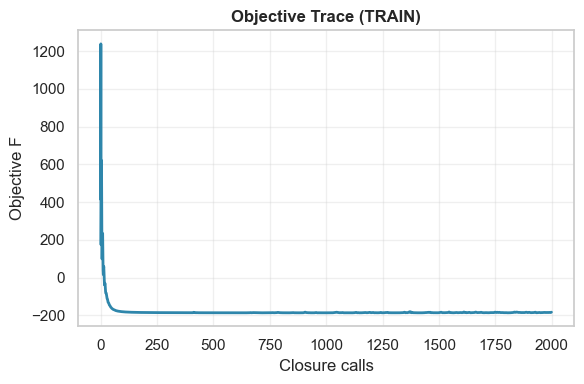

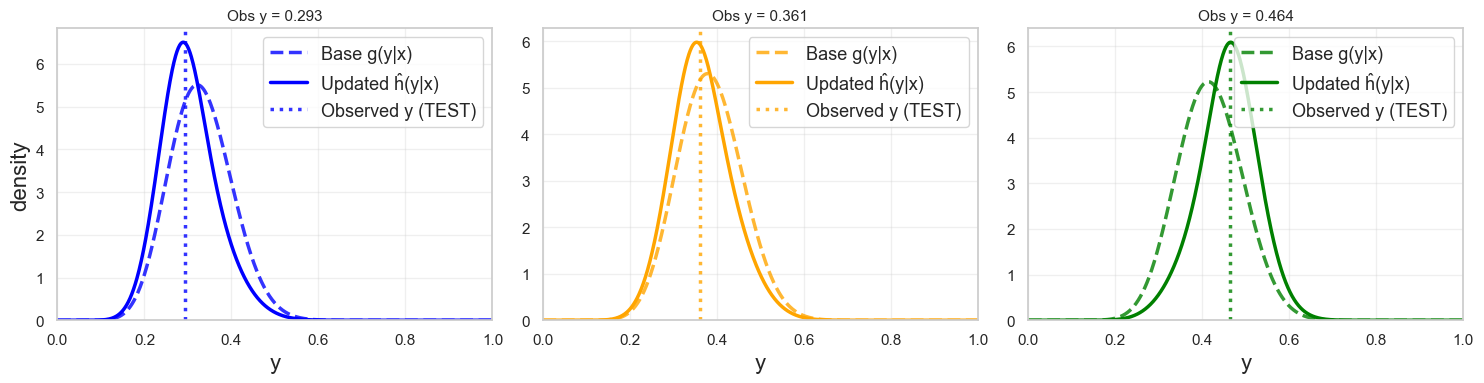

In [14]:
# Visualizations inspired by your logistic_gp_density_vi_multix notebook
import seaborn as sns
sns.set(style="whitegrid")

# 1) Optimization traces (F, TRAIN objective)
fig1, ax1 = plt.subplots(1,1, figsize=(6,4))
ax1.plot(range(len(trace["F"])), trace["F"], color="#2E86AB", linewidth=2)
ax1.set_title("Objective Trace (TRAIN)", fontweight="bold")
ax1.set_xlabel("Closure calls")
ax1.set_ylabel("Objective F")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
# Save figure
fig1.savefig("gp_objective_trace.pdf", dpi=200, bbox_inches="tight")
plt.show()

# 2) Density comparisons at three representative TEST covariates
np.random.seed(1)
idx_sorted = np.argsort(mu_hat_test)
sel_indices = [idx_sorted[int(0.1*len(idx_sorted))], idx_sorted[int(0.56*len(idx_sorted))], idx_sorted[int(0.9*len(idx_sorted))]]

# Estimate GAM residual standard deviation (pure Gaussian; no Beta helpers)
sigma_gam = None
try:
    if 'mu_hat_gam' in df_train.columns:
        resid_gam = df_train['y_adj'].to_numpy() - df_train['mu_hat_gam'].to_numpy()
        sigma_gam = float(np.std(resid_gam, ddof=1))
    elif 'gam' in locals():
        # fallback: use model-reported scale if available
        sigma_gam = float(np.sqrt(gam.statistics_.get('scale', np.nan)))
except Exception:
    sigma_gam = None
if (sigma_gam is None) or (not np.isfinite(sigma_gam)) or (sigma_gam <= 0):
    # final fallback: use std of training targets
    sigma_gam = float(np.std(df_train['y_adj'].to_numpy(), ddof=1))
    if (not np.isfinite(sigma_gam)) or (sigma_gam <= 0):
        sigma_gam = 1e-3

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
colors_density = ['blue', 'orange', 'green']
for j, (ax, ridx, col) in enumerate(zip(axes2, sel_indices, colors_density)):
    x_star = X_gp_test.iloc[ridx].to_dict()
    y_true = df_test["y_adj"].to_numpy()[ridx]
    # Pass full design row to align base mu with fitted model (TEST row)
    X_row = X_test.iloc[ridx]
    y_grid, g_vals, h_hat, exp_f, z_grid = model.predict_density(x_star_unscaled=x_star, X_row=X_row, df_row=df_test.iloc[ridx], y_min=1e-3, y_max=1-1e-3, M=1000)
    
    # Plot with consistent styling: same color for same x, different line styles for base vs updated
    ax.plot(y_grid, g_vals, '--', color=col, linewidth=2.5, alpha=0.8, label='Base g(y|x)')
    ax.plot(y_grid, h_hat, '-', color=col, linewidth=2.5, label='Updated ĥ(y|x)')
    ax.axvline(y_true, color=col, linestyle=':', linewidth=2.5, alpha=0.8, label='Observed y (TEST)')
    
    ax.set_title(f"Obs y = {y_true:.3f}", fontsize=11)
    ax.set_xlabel('y', fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    if j==0: ax.set_ylabel('density', fontsize=16)
    ax.legend(fontsize=13)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
# Save figure
fig2.savefig("density_comparisons_base_updated_TEST.pdf", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Updated-model mean (MC)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Ensure we have MC-based updated means on TEST; compute if missing
if 'mu_hat_updated_mc' not in df_test.columns:
    N_eval = len(df_test)
    M_grid = 600
    S_samples = 1000
    rng = np.random.default_rng(123)
    
    def sample_from_density_grid(y_grid: np.ndarray, h_hat: np.ndarray, size: int, rng: np.random.Generator) -> np.ndarray:
        dy = np.diff(y_grid)
        wts = np.zeros_like(y_grid)
        wts[0] = dy[0] / 2.0
        wts[-1] = dy[-1] / 2.0
        wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0
        prob = h_hat * wts
        prob_sum = prob.sum()
        if not np.isfinite(prob_sum) or prob_sum <= 0:
            prob = np.ones_like(prob) / prob.size
        else:
            prob = prob / prob_sum
        idx = rng.choice(y_grid.size, size=size, replace=True, p=prob)
        return y_grid[idx]
    
    updated_mean_mc = np.zeros(N_eval, dtype=float)
    for i in range(N_eval):
        x_star = X_gp_test.iloc[i].to_dict()
        X_row = X_test.iloc[i]
        y_grid, _, h_hat, _, _ = model.predict_density(x_star_unscaled=x_star, X_row=X_row, df_row=df_test.iloc[i], M=M_grid)
        ys = sample_from_density_grid(y_grid, h_hat, size=S_samples, rng=rng)
        updated_mean_mc[i] = float(ys.mean())
    df_test['mu_hat_updated_mc'] = updated_mean_mc


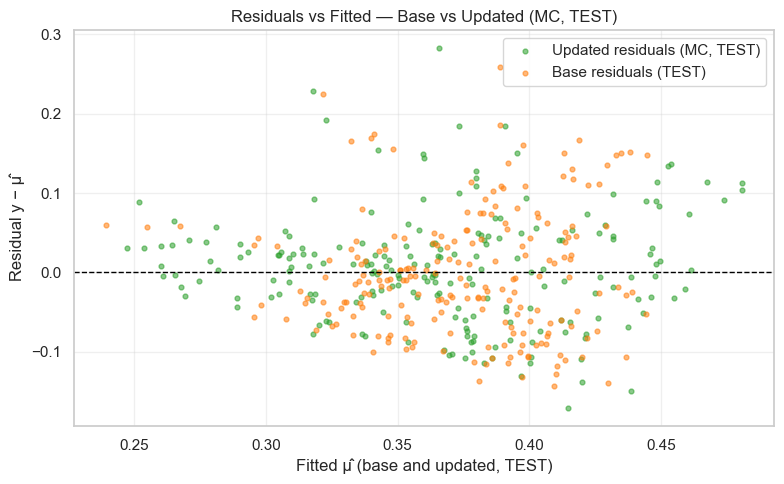

In [16]:
# Residuals overlay: Base vs Updated (MC point estimate) on TEST set
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Ensure base and updated TEST predictions exist
if 'mu_hat' not in df_test.columns:
    from scipy.special import expit
    mu_hat_test = expit(X_mat_test @ beta_hat)
    df_test['mu_hat'] = mu_hat_test

if 'mu_hat_updated_mc' not in df_test.columns:
    raise RuntimeError("Run the MC updated-mean TEST cell first to populate mu_hat_updated_mc in df_test.")

# Build arrays (TEST)
y_obs = df_test['y_adj'].to_numpy()
y_hat_base = df_test['mu_hat'].to_numpy()
y_hat_upd = df_test['mu_hat_updated_mc'].to_numpy()
resid_base = y_obs - y_hat_base
resid_upd = y_obs - y_hat_upd

# Single-axis overlay plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.scatter(y_hat_upd, resid_upd, s=12, alpha=0.55, color="#2ca02c", label="Updated residuals (MC, TEST)")
ax.scatter(y_hat_base, resid_base, s=12, alpha=0.55, color="#ff7f0e", label="Base residuals (TEST)")

ax.axhline(0.0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Fitted μ̂ (base and updated, TEST)")
ax.set_ylabel("Residual y − μ̂")
ax.set_title("Residuals vs Fitted — Base vs Updated (MC, TEST)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
# Save figure
fig.savefig("residuals_overlay_base_updated_mc_TEST.pdf", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
# Test log-likelihood on TEST: base Beta g vs updated GP ĥ (style matching toy logistic GP example)

loglik_base = 0.0
loglik_updated = 0.0

for i in range(len(df_test)):
    y_star = float(df_test["y_adj"].iloc[i])
    mu_star = float(df_test["mu_hat"].iloc[i])
    
    # Base Beta log density at (x_i, y_i)
    a_star = mu_star * phi_hat
    b_star = (1.0 - mu_star) * phi_hat
    log_g = (
        gammaln(a_star + b_star)
        - gammaln(a_star)
        - gammaln(b_star)
        + (a_star - 1.0) * np.log(y_star)
        + (b_star - 1.0) * np.log(1.0 - y_star)
    )
    loglik_base += log_g
    
    # Updated density ĥ via model.predict_density and interpolation
    x_star = X_gp_test.iloc[i].to_dict()
    X_row = X_test.iloc[i]
    y_grid, g_grid, h_hat, _, _ = model.predict_density(
        x_star_unscaled=x_star,
        X_row=X_row,
        df_row=df_test.iloc[i],
        y_min=1e-3,
        y_max=1-1e-3,
        M=1000,
    )
    hhat_interp = np.interp(y_star, y_grid, h_hat)
    hhat_interp = max(hhat_interp, 1e-12)
    loglik_updated += np.log(hhat_interp)

n_test = len(df_test)
print(f"TEST log-likelihood (base Beta g):     {loglik_base:.4f}  (per obs: {loglik_base / n_test:.6f})")
print(f"TEST log-likelihood (updated GP ĥ): {loglik_updated:.4f}  (per obs: {loglik_updated / n_test:.6f})")


TEST log-likelihood (base Beta g):     243.1235  (per obs: 1.157731)
TEST log-likelihood (updated GP ĥ): 285.3993  (per obs: 1.359044)


In [18]:
# Model Evaluation on TEST set: RMSE, Coverage, and Interval Length
import numpy as np
from scipy.stats import beta as beta_dist

# Number of samples for Monte Carlo estimation
n_samples = 2000
n_test = len(df_test)

# 1. Sample from base Beta regression model
def sample_from_base_model(X_row, n_samples):
    """Sample from base Beta(a, b) where a=mu*phi, b=(1-mu)*phi."""
    # X_row is from the already-transformed design matrix (with intercept)
    eta = beta_hat @ X_row.to_numpy()
    mu = expit(eta)
    a = mu * phi_hat
    b = (1.0 - mu) * phi_hat
    samples = beta_dist.rvs(a, b, size=n_samples, random_state=None)
    return samples

# 2. Sample from updated GP density model using inverse transform sampling
def sample_from_updated_model(x_star_unscaled, X_row, df_row, n_samples, M=1000):
    """Sample from updated density h(y|x) via inverse transform sampling."""
    y_grid, g_vals, h_hat, exp_f, z_grid = model.predict_density(
        x_star_unscaled=x_star_unscaled,
        X_row=X_row,
        df_row=df_row,
        y_min=1e-3,
        y_max=1-1e-3,
        M=M
    )
    
    # Compute weights for trapezoidal integration
    dy = np.diff(y_grid)
    wts = np.zeros_like(y_grid)
    wts[0] = dy[0] / 2.0
    wts[-1] = dy[-1] / 2.0
    wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0
    
    # Probability mass for each grid point
    prob = h_hat * wts
    prob = prob / prob.sum()
    
    # Sample via inverse transform
    samples = np.random.choice(y_grid, size=n_samples, replace=True, p=prob)
    return samples

# Storage for results
base_samples_all = []
updated_samples_all = []

print("Generating samples for TEST set...")
for i in range(n_test):
    if (i + 1) % 50 == 0:
        print(f"  Processing {i+1}/{n_test}...")
    
    X_row = X_test.iloc[i]  # Full design row (with intercept)
    x_star = X_gp_test.iloc[i].to_dict()  # GP features (unscaled)
    df_row = df_test.iloc[i]
    
    # Sample from base model
    base_samp = sample_from_base_model(X_row, n_samples)
    base_samples_all.append(base_samp)
    
    # Sample from updated model
    updated_samp = sample_from_updated_model(x_star, X_row, df_row, n_samples)
    updated_samples_all.append(updated_samp)

base_samples_all = np.array(base_samples_all)  # (n_test, n_samples)
updated_samples_all = np.array(updated_samples_all)  # (n_test, n_samples)

# ==========================
# Section 1: RMSE
# ==========================
y_test_np = df_test["y_adj"].to_numpy()

# Point predictions: mean of samples
pred_base = base_samples_all.mean(axis=1)
pred_updated = updated_samples_all.mean(axis=1)

rmse_base = np.sqrt(np.mean((y_test_np - pred_base)**2))
rmse_updated = np.sqrt(np.mean((y_test_np - pred_updated)**2))

print("\n" + "="*60)
print("Section 1: Root Mean Squared Error (RMSE)")
print("="*60)
print(f"Base model RMSE:    {rmse_base:.6f}")
print(f"Updated model RMSE: {rmse_updated:.6f}")


# ==========================
# Section 2: 95% Credible Interval Coverage
# ==========================
# Compute equal-tailed 95% credible intervals
lower_base = np.percentile(base_samples_all, 2.5, axis=1)
upper_base = np.percentile(base_samples_all, 97.5, axis=1)

lower_updated = np.percentile(updated_samples_all, 2.5, axis=1)
upper_updated = np.percentile(updated_samples_all, 97.5, axis=1)

# Coverage: fraction of observations within the interval
coverage_base = np.mean((y_test_np >= lower_base) & (y_test_np <= upper_base))
coverage_updated = np.mean((y_test_np >= lower_updated) & (y_test_np <= upper_updated))

print("\n" + "="*60)
print("Section 2: 95% Credible Interval Coverage")
print("="*60)
print(f"Base model coverage:    {coverage_base:.4f}")
print(f"Updated model coverage: {coverage_updated:.4f}")


# ==========================
# Section 3: Average Credible Interval Length
# ==========================
avg_length_base = np.mean(upper_base - lower_base)
avg_length_updated = np.mean(upper_updated - lower_updated)

print("\n" + "="*60)
print("Section 3: Average 95% Credible Interval Length")
print("="*60)
print(f"Base model avg length:    {avg_length_base:.6f}")
print(f"Updated model avg length: {avg_length_updated:.6f}")


Generating samples for TEST set...
  Processing 50/210...
  Processing 100/210...
  Processing 150/210...
  Processing 200/210...

Section 1: Root Mean Squared Error (RMSE)
Base model RMSE:    0.077712
Updated model RMSE: 0.070693

Section 2: 95% Credible Interval Coverage
Base model coverage:    0.9286
Updated model coverage: 0.9571

Section 3: Average 95% Credible Interval Length
Base model avg length:    0.285190
Updated model avg length: 0.277214


In [19]:
# # ============================
# # Part 1: Generate Hyperparameter Candidates with Latin Hypercube Sampling
# # ============================

# import time
# import pickle
# from dataclasses import dataclass
# from scipy.stats import qmc
# from scipy.spatial.distance import pdist, squareform

# # Define interpretable parameter ranges (same as weather data example)
# # Kernel variance: σ range → log(σ²)
# sigma_range = (0.01, 1.0)
# log_sigma2_range = (math.log(sigma_range[0]**2), math.log(sigma_range[1]**2))

# # Lengthscale in x: lx range → log(lx²)
# lx_range = (0.01, 1.0)
# log_lx2_range = (math.log(lx_range[0]**2), math.log(lx_range[1]**2))

# # Lengthscale in z: lz range → log(lz²)
# lz_range = (0.01, 1.0)
# log_lz2_range = (math.log(lz_range[0]**2), math.log(lz_range[1]**2))

# # Learning weight: log-scale range
# log_beta_range = (math.log(0.01), math.log(2000))

# # Inducing points: FIXED at 400 (consistent with cell 22)
# m_induce_fixed = 400

# # Generate initial LHS candidates
# n_candidates = 100
# sampler = qmc.LatinHypercube(d=4, seed=42)  # 4D: log_sigma2, log_lx2, log_lz2, beta
# lhs_samples = sampler.random(n=n_candidates)

# print(f"Generating {n_candidates} candidates using Latin Hypercube Sampling...")

# # LHS samples are already in [0, 1]^4
# candidates_normalized = lhs_samples.copy()

# print(f"✓ Created {len(candidates_normalized)} candidates from LHS\n")

# # Apply median heuristic to maximize minimal distance between candidates
# print("Optimizing candidate locations using median heuristic...")
# print("  Goal: Maximize the minimal pairwise distance between candidates")
# print("  Working in normalized [0, 1]^4 space for fair distance metric\n")

# max_iterations = 50
# learning_rate = 0.01

# for iteration in range(max_iterations):
#     # Compute pairwise distances in normalized space
#     dists = squareform(pdist(candidates_normalized, 'euclidean'))
    
#     # Set diagonal to infinity to avoid self-distances
#     np.fill_diagonal(dists, np.inf)
    
#     # Find minimum distance for each point
#     min_dists = np.min(dists, axis=1)
    
#     # Current objective: median of minimal distances
#     current_median_min_dist = np.median(min_dists)
    
#     # Find points with smallest minimal distances (need most improvement)
#     worst_points = np.argsort(min_dists)[:n_candidates // 10]  # Improve worst 10%
    
#     # Move worst points away from their nearest neighbors
#     for idx in worst_points:
#         nearest_neighbor_idx = np.argmin(dists[idx])
#         direction = candidates_normalized[idx] - candidates_normalized[nearest_neighbor_idx]
#         direction_norm = np.linalg.norm(direction)
        
#         if direction_norm > 1e-8:
#             # Move in direction away from nearest neighbor
#             candidates_normalized[idx] += learning_rate * direction / direction_norm
    
#     # Project back to [0, 1]^4 (clip to valid normalized range)
#     candidates_normalized = np.clip(candidates_normalized, 0.0, 1.0)

# # Final distance statistics
# dists_final = squareform(pdist(candidates_normalized, 'euclidean'))
# np.fill_diagonal(dists_final, np.inf)
# min_dists_final = np.min(dists_final, axis=1)

# print(f"\n✓ Optimization complete!")
# print(f"  Median minimal distance: {np.median(min_dists_final):.4f}")
# print(f"  Mean minimal distance:   {np.mean(min_dists_final):.4f}")
# print(f"  Min minimal distance:    {np.min(min_dists_final):.4f}\n")

# # Convert normalized [0, 1]^4 candidates to actual hyperparameter values
# print("Converting normalized candidates to hyperparameter space...")
# candidates = []

# for i in range(n_candidates):
#     # Extract normalized values
#     norm_log_sigma2 = candidates_normalized[i, 0]
#     norm_log_lx2 = candidates_normalized[i, 1]
#     norm_log_lz2 = candidates_normalized[i, 2]
#     norm_log_beta = candidates_normalized[i, 3]
    
#     # Scale to actual parameter ranges
#     log_sigma2 = log_sigma2_range[0] + norm_log_sigma2 * (log_sigma2_range[1] - log_sigma2_range[0])
#     log_lx2 = log_lx2_range[0] + norm_log_lx2 * (log_lx2_range[1] - log_lx2_range[0])
#     log_lz2 = log_lz2_range[0] + norm_log_lz2 * (log_lz2_range[1] - log_lz2_range[0])
#     log_beta = log_beta_range[0] + norm_log_beta * (log_beta_range[1] - log_beta_range[0])
#     beta = np.exp(log_beta)
    
#     candidates.append({
#         'log_sigma2': log_sigma2,
#         'log_lx2': log_lx2,
#         'log_lz2': log_lz2,
#         'beta': beta,
#         'm_induce': m_induce_fixed
#     })

# print(f"✓ Generated {len(candidates)} optimized hyperparameter candidates for cross-validation")


In [20]:
# # picle save the candidates for later use
# with open("hyperparameter_candidates_gini.pkl", "wb") as f:
#     pickle.dump(candidates, f)

In [21]:
# # pickle load candidates (if needed)
# with open("hyperparameter_candidates_gini.pkl", "rb") as f:
#     candidates = pickle.load(f)

In [22]:
# # ============================
# # Part 2: Cross-Validation Evaluation of Candidates
# # ============================

# # Update n_candidates to match actual candidates list size
# n_candidates = len(candidates)
# print(f"Testing with {n_candidates} candidates\n")

# # Custom KernelParams class for CV that supports log_lx2 parameter
# @dataclass
# class KernelParamsCV:
#     log_sigma2: float
#     log_lx2: float
#     log_lz2: float
    
#     def finalize(self, d_x):
#         """Create log_lx2 tensor for ARD"""
#         self.log_lx2_tensor = torch.log(torch.full((d_x,), self.lx2, dtype=torch.get_default_dtype()))
#         return self
    
#     @property
#     def sigma2(self): return math.exp(self.log_sigma2)
#     @property
#     def lx2(self):    return math.exp(self.log_lx2)
#     @property
#     def lz2(self):    return math.exp(self.log_lz2)


# def train_and_evaluate_model_cv(log_sigma2, log_lx2, log_lz2, beta, 
#                                   x_train_fold, y_train_fold, x_val_fold, y_val_fold,
#                                   mu_base_train_fold, phi_base_scaled, device, val_cv_indices):
#     """Train model on training fold and evaluate log score on validation fold."""
#     kp = KernelParamsCV(log_sigma2=log_sigma2, log_lx2=log_lx2, log_lz2=log_lz2)
#     kp = kp.finalize(x_train_fold.size(1))
    
#     try:
#         # Temporarily replace globals with fold-specific data for model initialization
#         global mu_base_train, phi_base
#         mu_base_train_backup = mu_base_train.copy()
#         phi_base_backup = phi_base
        
#         mu_base_train = mu_base_train_fold
#         phi_base = phi_base_scaled
        
#         # Create model with consistent parameters (m_induce=400, C=3, seed=2)
#         model_cv = BetaGPMixtureDiag(
#             x_train_fold, y_train_fold, C=3, m_induce=400, beta=beta, seed=2, 
#             kp=KernelParams(log_sigma2=log_sigma2, log_lx2=kp.log_lx2_tensor, log_lz2=log_lz2)
#         ).to(device)
        
#         # Restore global variables
#         mu_base_train = mu_base_train_backup
#         phi_base = phi_base_backup
        
#         # Adam optimizer with lr=0.5 (consistent with cell 22)
#         optimizer_cv = optim.Adam(model_cv.parameters(), lr=0.5)
        
#         # Training loop - 2000 iterations to match main training
#         num_iterations = 2000
#         for iteration in range(num_iterations):
#             optimizer_cv.zero_grad()
#             F, info = model_cv.forward_objective()
#             F.backward()
#             optimizer_cv.step()
        
#         # Evaluate log score on validation fold
#         total_log_score = 0.0
        
#         for i, val_idx in enumerate(val_cv_indices):
#             # Get the global training index for this validation sample
#             X_row_idx = train_idx[val_idx]
#             X_row = X.iloc[X_row_idx]
            
#             # Get x_star from the scaled GP features
#             x_star = {col: X_gp_train.iloc[val_idx][col] for col in X_gp_train.columns}
#             y_star = float(y_train[val_idx])
            
#             # Predict density
#             y_grid, g_vals, h_hat, _, _ = model_cv.predict_density(
#                 x_star_unscaled=x_star, X_row=X_row, y_min=1e-3, y_max=1-1e-3, M=1000
#             )
            
#             # Interpolate to get ĥ(y_star|x_star)
#             hhat_interp = np.interp(y_star, y_grid, h_hat)
#             total_log_score += np.log(max(hhat_interp, 1e-12))
        
#         return total_log_score
#     except Exception as e:
#         print(f"\nError in CV: {e}")
#         import traceback
#         traceback.print_exc()
#         return None


# # Prepare 3-fold cross-validation splits on training data
# n_train_cv = len(y_train)
# fold_size = n_train_cv // 3
# cv_seed = 42
# cv_indices = np.random.RandomState(cv_seed).permutation(n_train_cv)

# fold_indices = [
#     cv_indices[:fold_size],
#     cv_indices[fold_size:2*fold_size],
#     cv_indices[2*fold_size:]
# ]

# # Evaluate all candidates using 3-fold CV
# all_results = []
# results_file = "cv_results_gini.pkl"
# start_time = time.time()

# print("\n" + "="*70)
# print(f"Starting 3-fold cross-validation on {n_train_cv} training samples...")
# print(f"  Evaluating {n_candidates} candidates")
# print(f"  Fold sizes: {[len(fold) for fold in fold_indices]}")
# print(f"  Results saved after each candidate to: {results_file}")
# print("="*70 + "\n")

# for idx in range(n_candidates):
#     candidate = candidates[idx]
    
#     # Perform 3-fold cross-validation for this candidate
#     cv_scores = []
    
#     for fold_id in range(3):
#         # Use one fold as validation, others as training
#         val_cv_indices = fold_indices[fold_id]
#         train_cv_indices = np.concatenate([fold_indices[i] for i in range(3) if i != fold_id])
        
#         x_train_fold = torch.from_numpy(X_gp_scaled[train_cv_indices]).to(torch.float64).to(device)
#         y_train_fold = torch.from_numpy(y_train[train_cv_indices]).to(torch.float64).to(device)
#         x_val_fold = torch.from_numpy(X_gp_scaled[val_cv_indices]).to(torch.float64).to(device)
#         y_val_fold = torch.from_numpy(y_train[val_cv_indices]).to(torch.float64).to(device)
        
#         # Get base model parameters for training fold
#         mu_base_train_fold = mu_hat_train[train_cv_indices]
        
#         # Train and evaluate
#         score = train_and_evaluate_model_cv(
#             candidate['log_sigma2'], candidate['log_lx2'], candidate['log_lz2'],
#             candidate['beta'],
#             x_train_fold, y_train_fold, x_val_fold, y_val_fold,
#             mu_base_train_fold, phi_base, device, val_cv_indices
#         )
        
#         if score is not None:
#             cv_scores.append(score)
    
#     # Average log score across the 3 folds
#     if len(cv_scores) == 3:
#         avg_log_score = np.mean(cv_scores)
#         result = {
#             'log_sigma2': candidate['log_sigma2'],
#             'log_lx2': candidate['log_lx2'],
#             'log_lz2': candidate['log_lz2'],
#             'beta': candidate['beta'],
#             'm_induce': candidate['m_induce'],
#             'avg_log_score': avg_log_score,
#             'fold_scores': cv_scores
#         }
#         all_results.append(result)
        
#         # Save results immediately after each candidate
#         with open(results_file, "wb") as f:
#             pickle.dump(all_results, f)
    
#     # Progress tracking
#     elapsed = time.time() - start_time
#     est_total = elapsed * n_candidates / (idx + 1) if idx > 0 else 0
#     est_remaining = est_total - elapsed
    
#     if len(cv_scores) == 3:
#         print(f"Candidate {idx+1}/{n_candidates} | Score: {avg_log_score:.2f} | "
#               f"Elapsed: {elapsed/60:.1f}min | Remaining: ~{est_remaining/60:.1f}min")
#     else:
#         print(f"Candidate {idx+1}/{n_candidates} | FAILED | "
#               f"Elapsed: {elapsed/60:.1f}min | Remaining: ~{est_remaining/60:.1f}min")

# print("\n" + "="*70)
# print(f"✓ Cross-validation complete!")
# print(f"  Total time: {(time.time() - start_time)/60:.1f} minutes")
# print(f"  Successful evaluations: {len(all_results)}/{n_candidates}")
# print(f"  Results saved to: {results_file}")
# print("="*70)


In [23]:
# # Find best hyperparameters and visualize results
# if len(all_results) > 0:
#     all_results_sorted = sorted(all_results, key=lambda x: x['avg_log_score'], reverse=True)
#     best = all_results_sorted[0]
    
#     print("\n" + "="*70)
#     print("BEST HYPERPARAMETERS (3-Fold Cross-Validation)")
#     print("="*70)
#     print(f"  σ = {np.sqrt(np.exp(best['log_sigma2'])):.4f}")
#     print(f"  lx = {np.sqrt(np.exp(best['log_lx2'])):.4f}")
#     print(f"  lz = {np.sqrt(np.exp(best['log_lz2'])):.4f}")
#     print(f"  β = {best['beta']:.2f}")
#     print(f"  m = {best['m_induce']}")
#     print(f"\nAverage validation log-score: {best['avg_log_score']:.4f}")
#     print("="*70)
    
#     # Display top 5 candidates
#     print("\n" + "="*70)
#     print("TOP 5 HYPERPARAMETER CANDIDATES")
#     print("="*70)
#     for rank, result in enumerate(all_results_sorted[:5], 1):
#         print(f"\nRank {rank}:")
#         print(f"  σ = {np.sqrt(np.exp(result['log_sigma2'])):.4f}, "
#               f"lx = {np.sqrt(np.exp(result['log_lx2'])):.4f}, "
#               f"lz = {np.sqrt(np.exp(result['log_lz2'])):.4f}, "
#               f"β = {result['beta']:.2f}, "
#               f"m = {result['m_induce']}")
#         print(f"  Avg log-score: {result['avg_log_score']:.4f}")
#     print("="*70)
    
#     # Save results
#     with open("hyperparameter_search_cv_results_gini.pkl", "wb") as f:
#         pickle.dump({'best': best, 'all_results': all_results}, f)
#     print("\nResults saved to hyperparameter_search_cv_results_gini.pkl")
# else:
#     print("\nNo successful evaluations!")
